# Sprint 1 - Airline Passenger Satisfaction

Notebook realizuje: ingest CSV do SQLite, EDA, podzial train/val/test oraz baseline model klasyfikacyjny.

In [1]:
from pathlib import Path
import json
import sqlite3

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
raw_dir = project_root / 'data' / '01_raw'
dataset_csv_path = raw_dir / 'airline_passenger_satisfaction.csv'
db_path = raw_dir / 'airline_passenger_satisfaction.sqlite'
metrics_path = project_root / 'reports' / 'metrics' / 'baseline_metrics.json'

raw_dir.mkdir(parents=True, exist_ok=True)
metrics_path.parent.mkdir(parents=True, exist_ok=True)

if not dataset_csv_path.exists():
    raise FileNotFoundError(
        f'Brak pliku CSV. Umiesc airline_passenger_satisfaction.csv w: {raw_dir}'
    )

print(f'Project root: {project_root}')
print(f'Dataset CSV: {dataset_csv_path}')
print(f'SQLite DB: {db_path}')

Project root: /Users/lidiakongiel/ASI_12c_3
Dataset CSV: /Users/lidiakongiel/ASI_12c_3/data/01_raw/airline_passenger_satisfaction.csv
SQLite DB: /Users/lidiakongiel/ASI_12c_3/data/01_raw/airline_passenger_satisfaction.sqlite


In [3]:
raw_df = pd.read_csv(dataset_csv_path)

with sqlite3.connect(db_path) as conn:
    raw_df.to_sql('passengers', conn, if_exists='replace', index=False)

with sqlite3.connect(db_path) as conn:
    train_df = pd.read_sql_query('SELECT * FROM passengers', conn)

print('SQLite ingest complete.')
print(f'dataset shape: {train_df.shape}')

SQLite ingest complete.
dataset shape: (129880, 24)


In [4]:
train_df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [5]:
train_df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,129880.0,NaN,NaN,NaN,64940.5,37493.270818,1.0,32470.75,64940.5,97410.25,129880.0
Gender,129880,2,Female,65899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Customer Type,129880,2,Returning,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Travel,129880,2,Business,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,129880.0,NaN,NaN,NaN,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Departure Delay,129880.0,NaN,NaN,NaN,14.713713,38.071126,0.0,0.0,0.0,12.0,1592.0
Arrival Delay,129487.0,NaN,NaN,NaN,15.091129,38.46565,0.0,0.0,0.0,13.0,1584.0
Departure and Arrival Time Convenience,129880.0,NaN,NaN,NaN,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0


In [6]:
missing_counts = train_df.isna().sum().sort_values(ascending=False)
duplicate_count = int(train_df.duplicated().sum())

print('Top missing values:')
display(missing_counts.head(15))
print(f'Duplicate rows in train: {duplicate_count}')

Top missing values:


Arrival Delay              393
ID                           0
Gate Location                0
Baggage Handling             0
In-flight Entertainment      0
In-flight Wifi Service       0
In-flight Service            0
Food and Drink               0
Cleanliness                  0
Leg Room Service             0
Seat Comfort                 0
On-board Service             0
Online Boarding              0
Gender                       0
Check-in Service             0
dtype: int64

Duplicate rows in train: 0


In [7]:
target_col = 'Satisfaction'
if target_col not in train_df.columns:
    raise ValueError(f'Kolumna target {target_col} nie istnieje w danych train.')

id_candidates = ['Unnamed: 0', 'id', 'ID']
feature_df = train_df.drop(columns=[c for c in id_candidates if c in train_df.columns], errors='ignore').copy()

## Wizualizacje EDA

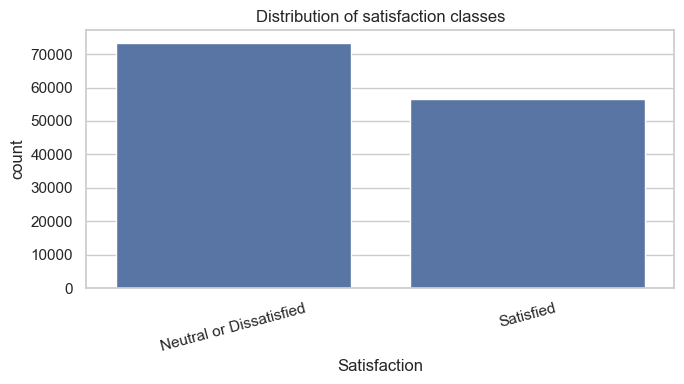

In [8]:
# 1) Rozklad klasy target
plt.figure(figsize=(7, 4))
sns.countplot(data=feature_df, x=target_col)
plt.title('Distribution of satisfaction classes')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

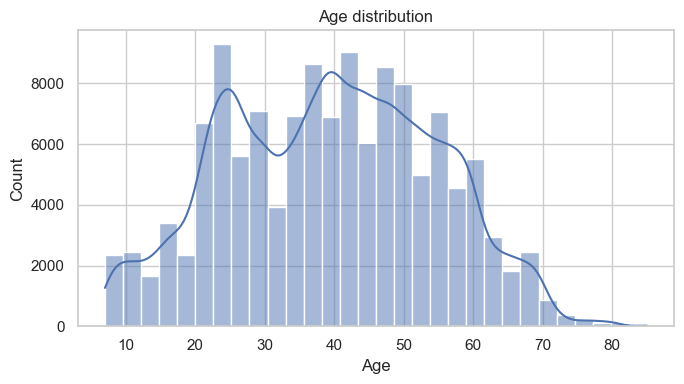

In [9]:
# 2) Histogram wybranej cechy numerycznej
numeric_cols = feature_df.select_dtypes(include=['number']).columns.tolist()
hist_col = 'Age' if 'Age' in numeric_cols else (numeric_cols[0] if numeric_cols else None)
if hist_col is None:
    raise ValueError('Brak cech numerycznych do histogramu.')

plt.figure(figsize=(7, 4))
sns.histplot(data=feature_df, x=hist_col, bins=30, kde=True)
plt.title(f'{hist_col} distribution')
plt.tight_layout()
plt.show()

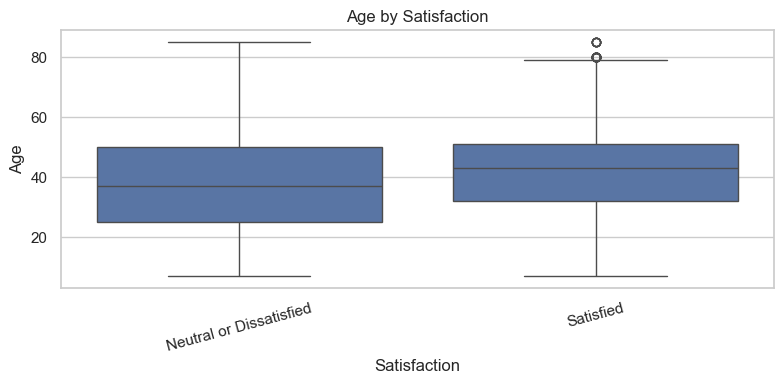

In [10]:
# 3) Boxplot wybranej cechy numerycznej wzgledem targetu
box_col = 'Departure Delay in Minutes' if 'Departure Delay in Minutes' in numeric_cols else hist_col

plt.figure(figsize=(8, 4))
sns.boxplot(data=feature_df, x=target_col, y=box_col)
plt.title(f'{box_col} by {target_col}')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

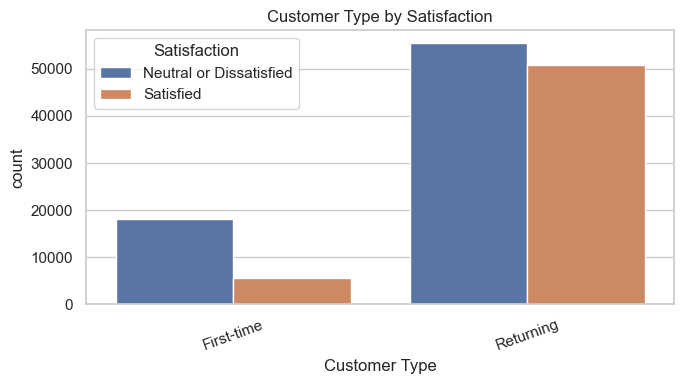

In [11]:
# 4) Rozklad wybranej cechy kategorycznej wzgledem targetu
categorical_cols = [c for c in feature_df.select_dtypes(exclude=['number']).columns if c != target_col]
cat_col = 'Customer Type' if 'Customer Type' in categorical_cols else (categorical_cols[0] if categorical_cols else None)

if cat_col is None:
    plot_df = feature_df.assign(target_for_visual=feature_df[target_col])
    cat_col = 'target_for_visual'
else:
    plot_df = feature_df

plt.figure(figsize=(7, 4))
sns.countplot(data=plot_df, x=cat_col, hue=target_col)
plt.title(f'{cat_col} by {target_col}')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

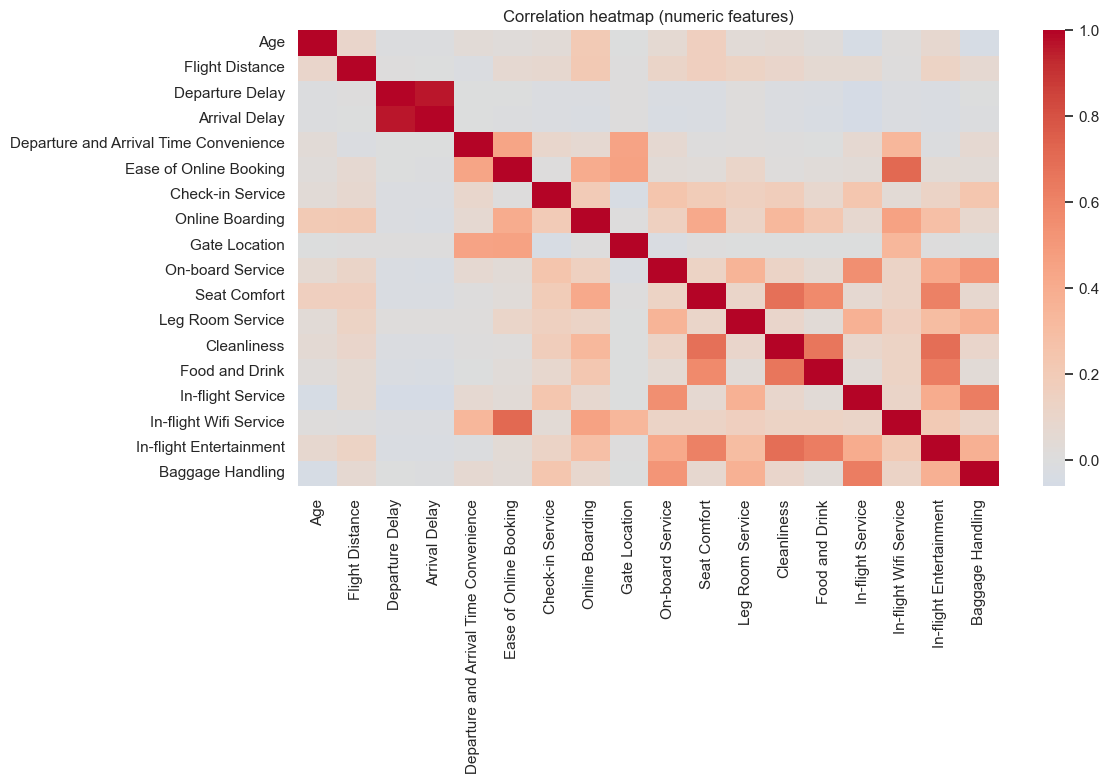

In [12]:
# 5) Korelacje cech numerycznych
corr_cols = numeric_cols[:]
if len(corr_cols) == 0:
    feature_df = feature_df.copy()
    feature_df['constant_col'] = 1
    corr_cols = ['constant_col']
elif len(corr_cols) == 1:
    feature_df = feature_df.copy()
    feature_df['constant_col'] = 1
    corr_cols = [corr_cols[0], 'constant_col']

corr = feature_df[corr_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.show()

## Split 70/15/15 oraz baseline model

In [13]:
X = feature_df.drop(columns=[target_col])
y = feature_df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

print('Split sizes:')
print(f'train: {X_train.shape[0]} ({X_train.shape[0]/len(X):.2%})')
print(f'val:   {X_val.shape[0]} ({X_val.shape[0]/len(X):.2%})')
print(f'test:  {X_test.shape[0]} ({X_test.shape[0]/len(X):.2%})')

Split sizes:
train: 90916 (70.00%)
val:   19482 (15.00%)
test:  19482 (15.00%)


In [14]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)),
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [15]:
y_val_pred = baseline_model.predict(X_val)

metrics = {
    'accuracy': float(accuracy_score(y_val, y_val_pred)),
    'precision_macro': float(precision_score(y_val, y_val_pred, average='macro', zero_division=0)),
    'recall_macro': float(recall_score(y_val, y_val_pred, average='macro', zero_division=0)),
    'f1_macro': float(f1_score(y_val, y_val_pred, average='macro', zero_division=0)),
}

unique_classes = sorted(pd.Series(y_train).dropna().unique().tolist())
if len(unique_classes) == 2 and hasattr(baseline_model, 'predict_proba'):
    positive_class = unique_classes[1]
    class_to_idx = {cls: idx for idx, cls in enumerate(baseline_model.named_steps['model'].classes_)}
    if positive_class in class_to_idx:
        y_val_binary = (y_val == positive_class).astype(int)
        y_val_proba = baseline_model.predict_proba(X_val)[:, class_to_idx[positive_class]]
        metrics['roc_auc'] = float(roc_auc_score(y_val_binary, y_val_proba))
    else:
        metrics['roc_auc'] = None
else:
    metrics['roc_auc'] = None

metrics

{'accuracy': 0.9618109023714198,
 'precision_macro': 0.9630293884927859,
 'recall_macro': 0.9593355742673699,
 'f1_macro': 0.9609948138787408,
 'roc_auc': 0.9942560909952814}

In [16]:
metrics_payload = {
    'dataset': 'airline_passenger_satisfaction',
    'split': {
        'train': int(X_train.shape[0]),
        'val': int(X_val.shape[0]),
        'test': int(X_test.shape[0]),
    },
    'model': 'RandomForestClassifier',
    'metrics_scope': 'validation',
    'validation_metrics': metrics,
}

with metrics_path.open('w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, ensure_ascii=True, indent=2)

print(f'Metrics saved to: {metrics_path}')

Metrics saved to: /Users/lidiakongiel/ASI_12c_3/reports/metrics/baseline_metrics.json
